In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:

def steady_state(P: np.ndarray) -> np.ndarray:    
    vals, vecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(vals - 1.0))
    v = np.real(vecs[:, idx])
    v = v / np.sum(v)
    v = np.maximum(v, 0)
    return v / np.sum(v)

def evolve_counts(v0: np.ndarray, P: np.ndarray, steps: int) -> np.ndarray:
    traj = [v0.astype(float)]
    v = v0.astype(float).copy()
    for _ in range(steps):
        v = v @ P
        traj.append(v.copy())
    return np.vstack(traj)

In [14]:
# Estados: 0:A (Coca-Cola), 1:B (Pepsi), 2:C (Del Valle)
labels = ["A (Coca-Cola)", "B (Pepsi)", "C (Del Valle)"]
P = np.array([
    [0.60, 0.30, 0.10],  # desde A
    [0.30, 0.50, 0.20],  # desde B
    [0.40, 0.30, 0.30],  # desde C
], dtype=float)


In [15]:
def inciso_A():
    poblacion_inicial = np.array([200, 300, 500], dtype=float) 
    v1 = poblacion_inicial @ P
    print("Inciso A) Distribución tras 1 paso desde (200,300,500): ")
    for lab, val in zip(labels, v1):
        print(f"{lab}: {val:.2f}")
    print("Suma:", np.sum(v1))
    return v1

In [16]:
def inciso_B():
    population = 50_000_000
    liters_per_week_per_capita = 1.0
    weeks_per_year = 52
    annual_total = population * liters_per_week_per_capita * weeks_per_year
    
    pi = steady_state(P)
    liters_by_brand = annual_total * pi
    
    print("\nInciso B) Consumo anual total y por compañía: ")
    print(f"Consumo anual total (L): {annual_total:,.0f}")
    for lab, lit in zip(labels, liters_by_brand):
        print(f"{lab}: {lit:,.0f} L  ({100*lit/annual_total:.2f}%)")
    

    plt.figure()
    plt.bar(labels, liters_by_brand)
    plt.title("Consumo anual por compañía (litros)")
    plt.ylabel("Litros")
    plt.xlabel("Compañía")
    plt.tight_layout()
    plt.show()
    return liters_by_brand, pi

In [17]:
def inciso_C(pi):
    weeks = 52
    P_campaign = P.copy()

    # Ajustar la fila de C (índice 2): [0.40,0.30,0.30] -> [0.342857,0.257143,0.40]
    orig_CA, orig_CB, orig_CC = P_campaign[2, 0], P_campaign[2, 1], P_campaign[2, 2]
    delta = 0.10  # aumento a C->C
    leaving = orig_CA + orig_CB
    new_CC = orig_CC + delta
    new_CA = orig_CA - delta * (orig_CA / leaving)
    new_CB = orig_CB - delta * (orig_CB / leaving)
    new_rowC = np.array([new_CA, new_CB, new_CC], dtype=float)
    new_rowC = np.clip(new_rowC, 0.0, 1.0)
    new_rowC = new_rowC / np.sum(new_rowC)
    P_campaign[2] = new_rowC

    # Simular trayectoria (personas) por 52 semanas partiendo del estacionario base
    population = 50_000_000
    v_start = pi * population
    traj_base = evolve_counts(v_start, P, weeks)
    traj_camp = evolve_counts(v_start, P_campaign, weeks)

    # Ventas semanales (1 L/persona/semana) ≈ conteos al inicio de cada semana
    weekly_base = traj_base[:-1]      # semanas 1..52
    weekly_camp = traj_camp[:-1]

    incremental_by_week = weekly_camp - weekly_base
    incremental_C_liters = float(np.sum(incremental_by_week[:, 2]))

    # Dos interpretaciones del enunciado:
    profit_hi = 0.25    # $0.25 por litro (25 centavos de dólar)
    profit_lo = 0.0025  # $0.0025 por litro (0.25 centavos)
    investment = 20_000_000.0

    extra_hi = incremental_C_liters * profit_hi
    extra_lo = incremental_C_liters * profit_lo

    print("\nInciso C) Campaña de C (+10 p.p. C->C por 1 año)")
    print("Fila de C (antes): [0.40, 0.30, 0.30]")
    print("Fila de C (campaña): [{:.6f}, {:.6f}, {:.6f}]".format(*P_campaign[2]))
    print(f"Δ Litros C en 1 año: {incremental_C_liters:,.0f}")
    print("\n- Utilidad $0.25 por L: ${:,.2f} -> {} conviene (vs $20,000,000)".format(
        extra_hi, "SÍ" if extra_hi > investment else "NO"))
    print("- Utilidad $0.0025 por L: ${:,.2f} -> {} conviene (vs $20,000,000)".format(
        extra_lo, "SÍ" if extra_lo > investment else "NO"))
    return {
        "P_campaign_rowC": P_campaign[2].tolist(),
        "incremental_C_liters": incremental_C_liters,
        "extra_profit_hi": extra_hi,
        "extra_profit_lo": extra_lo,
        "investment": investment
    }

Matriz de transición P:
[[0.6 0.3 0.1]
 [0.3 0.5 0.2]
 [0.4 0.3 0.3]]

Distribución estacionaria (largo plazo):
A (Coca-Cola): 0.453125
B (Pepsi): 0.375000
C (Del Valle): 0.171875
Inciso A) Distribución tras 1 paso desde (200,300,500): 
A (Coca-Cola): 410.00
B (Pepsi): 360.00
C (Del Valle): 230.00
Suma: 1000.0

Inciso B) Consumo anual total y por compañía: 
Consumo anual total (L): 2,600,000,000
A (Coca-Cola): 1,178,125,000 L  (45.31%)
B (Pepsi): 975,000,000 L  (37.50%)
C (Del Valle): 446,875,000 L  (17.19%)


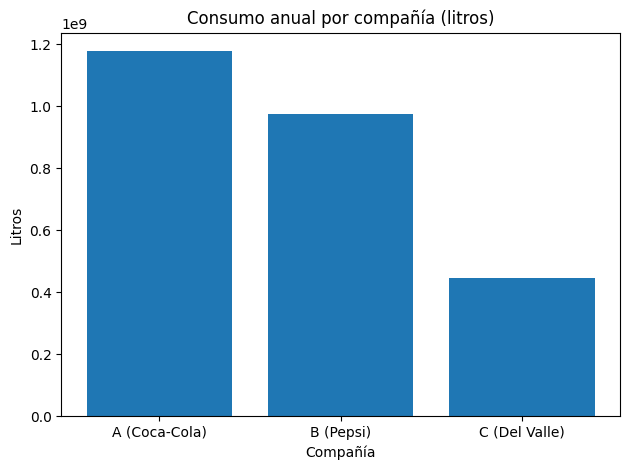


Inciso C) Campaña de C (+10 p.p. C->C por 1 año)
Fila de C (antes): [0.40, 0.30, 0.30]
Fila de C (campaña): [0.342857, 0.257143, 0.400000]
Δ Litros C en 1 año: 58,418,222

- Utilidad $0.25 por L: $14,604,555.56 -> NO conviene (vs $20,000,000)
- Utilidad $0.0025 por L: $146,045.56 -> NO conviene (vs $20,000,000)


In [18]:
if __name__ == "__main__":
    np.set_printoptions(precision=6, suppress=True)

    # Mostrar matriz P y estacionario
    print("Matriz de transición P:")
    print(P)
    pi = steady_state(P)
    print("\nDistribución estacionaria (largo plazo):")
    for lab, p in zip(labels, pi):
        print(f"{lab}: {p:.6f}")

    # Incisos
    _ = inciso_A()
    liters_by_brand, pi = inciso_B()
    _ = inciso_C(pi)